In [3]:
# Enable autoreload to automatically reload modules before executing code
%load_ext autoreload
%autoreload 2

# Imports
import torch
import numpy as np
import random

from utils import load_model
from improvement.policy import get_options, eval_dataset

# Set random seeds for reproducibility
SEED = 3333
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Problem configuration
graph_size = 200
agent_num = 5

# Load options
opts = get_options(graph_size=graph_size, agent_num=agent_num)
opts.device = torch.device("cuda:1")  # Set to the desired CUDA device
opts.sample_size = opts.val_size     # Match sample size with validation set
opts.eval_batch_size = 1           # Set evaluation batch size

# Load pre-trained CMIP model
model_path = 'pretrain/CMIP_constructive/epoch-20.pt'  
model_CM, _ = load_model(model_path, agent_num=agent_num)
model_CM = model_CM.to(opts.device)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  [*] Loading model from pretrain/CMIP_constructive/epoch-20.pt


# Visualize CPE using t-SNE


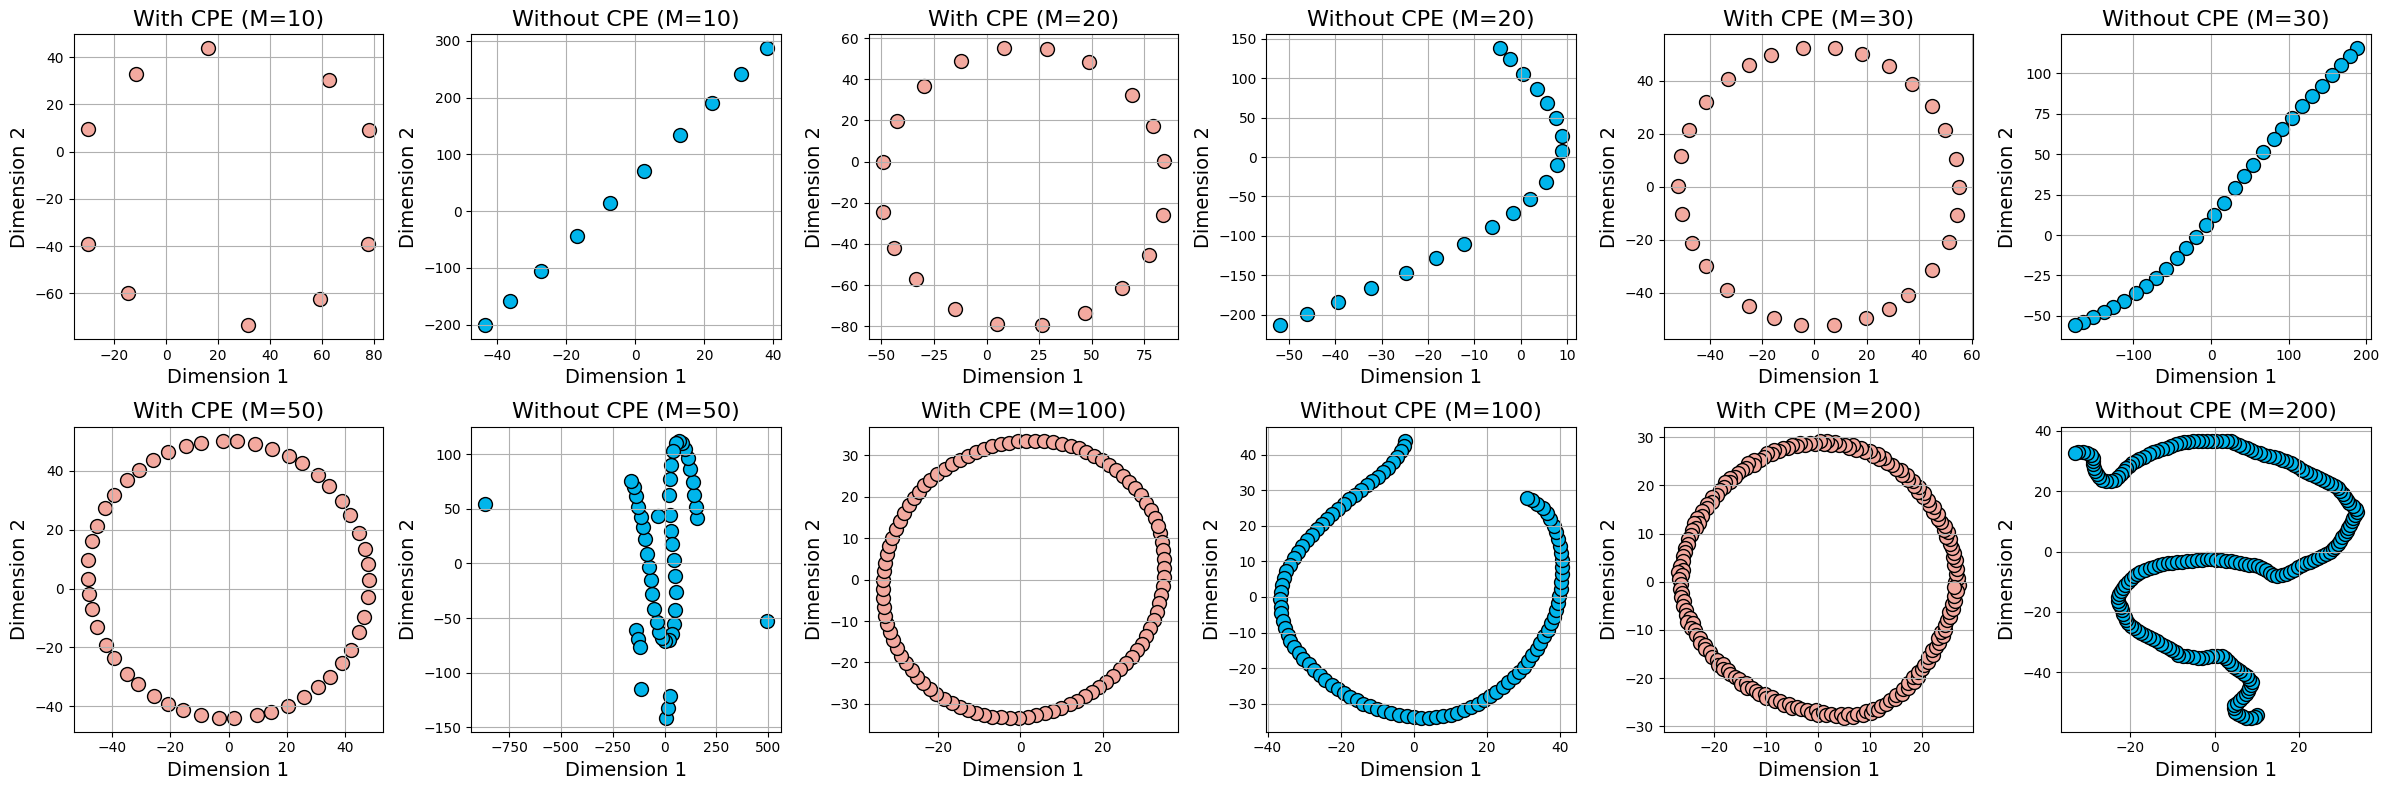

In [4]:
import torch
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Move model to CPU
model_CM = model_CM.to('cpu')

def tsne_reduce(data: torch.Tensor, perplexity: int = 5) -> torch.Tensor:
    n = len(data)
    if n <= 50:
        perplexity = 2
    elif n <= 100:
        perplexity = 5
    elif n <= 200:
        perplexity = 10

    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    return tsne.fit_transform(data.numpy())

def plot_embedding(ax, data_2d, title, color):
    ax.scatter(data_2d[:, 0], data_2d[:, 1], c=color, marker='o', edgecolors='k', s=100)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Dimension 1', fontsize=14)
    ax.set_ylabel('Dimension 2', fontsize=14)
    ax.grid(True)

# Sample sizes arranged in 2 rows x 6 columns
sample_settings = [
    [10, 10, 20, 20, 30, 30],
    [50, 50, 100, 100, 200, 200]
]

fig, axs = plt.subplots(2, 6, figsize=(24, 8))  # 2 rows, 6 columns of subplots

for row in range(2):
    for col in range(6):
        num_samples = sample_settings[row][col]

        # Compute cyclic positional encoding
        circle_encoding = model_CM.cyclic_position_encoding_pattern(num_samples, 128)

        # Compute absolute positional encoding and scale by model parameters
        abs_encoding = model_CM.positional_encoding(1, num_samples)
        abs_encoding = model_CM.alpha * model_CM.pos_emb_proj(abs_encoding) / model_CM.agent_num
        abs_encoding = abs_encoding.detach()

        # Apply t-SNE dimensionality reduction
        circle_2d = tsne_reduce(circle_encoding)
        abs_2d = tsne_reduce(abs_encoding)

        ax = axs[row, col]

        # Even columns: With CPE; Odd columns: Without CPE
        if col % 2 == 0:
            plot_embedding(ax, circle_2d, f'With CPE (M={num_samples})', '#f3a99f')
        else:
            plot_embedding(ax, abs_2d, f'Without CPE (M={num_samples})', '#00b5eb')

plt.tight_layout()
plt.show()
